<a href="https://colab.research.google.com/github/Vishaal1409/alzheimers-disease-detection/blob/main/alzheimers_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## About this Project

This project uses a real-world clinical dataset of 2,149 patients to build a model that predicts whether a patient has Alzheimer's Disease or not.

I had originally planned to work on a credit card fraud detection dataset. The day I was filling out the Google Form to confirm my project dataset, I was with a friend who was working on his 3rd year ML project and he was
telling me how boring hospital healthcare data were but something about it clicked for me, it didn't bore me.

I realised I wanted to work on something where the features actually mean something I can understand and explain. Age, memory complaints, cognitive scores. These felt real compared to columns just named V1, V2 from a bank dataset.

So I went back, found this Alzheimer's dataset on Kaggle and changed my project dataset and idea.

## Step 1 — Loading and Understanding the Data

Before doing anything else, I want to load the data and get a feel for
what I'm working with, how many rows, what columns exist, any missing
values, and what the target variable looks like.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#importing the basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/alzheimers-disease-detection/alzheimers_disease_data.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### What I see so far

The dataset has **2,149 rows and 35 columns.**

Each row is one patient. The columns cover a wide range of information:
- **PatientID** - just an ID number, not useful for modeling
- **Age, Gender, Ethnicity, EducationLevel** — demographic info
- **BMI, Smoking, AlcoholConsumption, PhysicalActivity, DietQuality** — lifestyle factors
- **MemoryComplaints, BehavioralProblems, ADL, Confusion, Disorientation,
  PersonalityChanges, DifficultyCompleting** — symptoms and daily functioning
- **Diagnosis** — this is our **target variable**. 0 = No Alzheimer's, 1 = Alzheimer's

Unlike the fraud dataset where columns were hidden with PCA, here every
column has a real meaning I can actually understand and explain.

In [7]:
#checking data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

### Data Types & Structure

The dataset has 35 columns total:
- 22 are integers (int64) — things like Age, Gender, binary yes/no columns
- 12 are floats (float64) — things like BMI, cholesterol levels, MMSE score
- 1 is object (text) — DoctorInCharge, which is just a doctor's name

The DoctorInCharge column has no useful information for predicting
Alzheimer's, a doctor's name won't help the model learn patterns.
So I'll drop it during preprocessing.

In [8]:
#checking missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Missing values in each column:
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
Difficul

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
#checking class distribution (how many Alzheimer's vs No Alzheimer's)
print("Class distribution:")
print(df['Diagnosis'].value_counts())

print("\nPercentage:")
print(df['Diagnosis'].value_counts(normalize=True) * 100)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Percentage:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


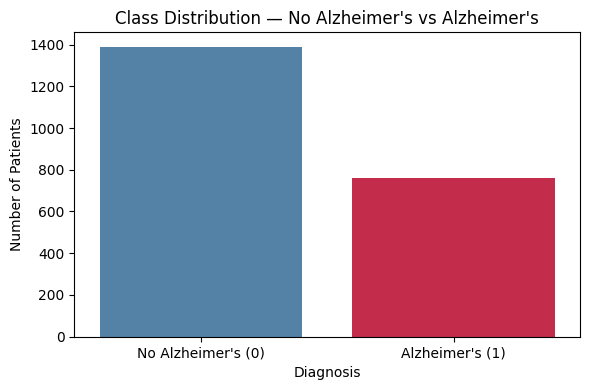

In [10]:
#visualizing
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', hue='Diagnosis', data=df,
              palette=['steelblue', 'crimson'], legend=False)
plt.title("Class Distribution — No Alzheimer's vs Alzheimer's")
plt.xticks([0, 1], ["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### Class Distribution

Out of 2,149 patients:
- **1,389 (64.6%) have no Alzheimer's (Class 0)**
- **760 (35.4%) have Alzheimer's (Class 1)**

This is a mild class imbalance not as extreme as the fraud dataset
(which was 99.8% vs 0.2%), but still noticeable. The model might
lean towards predicting "No Alzheimer's" more often just because
there are more of those cases.

I'll handle this during preprocessing using SMOTE, a technique
that creates synthetic samples of the minority class to balance things out.

Also, accuracy alone won't be a reliable metric here. I'll use
Precision, Recall, and F1-Score to actually measure how well the
model catches Alzheimer's cases.

## Step 2 — Data Cleaning & Preprocessing

Now that I understand the data, I need to prepare it before feeding
it into any model. Raw data has issues that can confuse or mislead
the model, so this step fixes all of that.

Three things I'm doing here:
1. **Drop columns that don't help** — PatientID is just a number,
   DoctorInCharge is a name. Neither tells us anything about Alzheimer's.
2. **Scale numerical features** — columns like BMI and AlcoholConsumption
   are on very different scales. Scaling brings them to the same range
   so no single column dominates the model unfairly.
3. **Handle class imbalance with SMOTE** — 65% vs 35% split means the
   model might be biased. SMOTE creates synthetic Alzheimer's samples
   to balance the dataset.

In [11]:
#dropping columns that are not useful for prediction
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

print("Shape after dropping useless columns:", df_clean.shape)
df_clean.head()

Shape after dropping useless columns: (2149, 33)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [12]:
#separating features (X) and target variable (y)
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2149, 32)
Target shape: (2149,)


### Separating Features and Target

I split the dataset into:
- **X** — all the input columns (33 features) that the model will learn from
- **y** — the Diagnosis column, which is what the model is trying to predict

This is standard practice before any preprocessing or modeling step.

In [13]:
from sklearn.preprocessing import StandardScaler

#these are columns with continuous numerical values that need scaling
cols_to_scale = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
                 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
                 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
                 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("Scaling done!")
X_scaled.head()

Scaling done!


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,-0.212368,0,0,2,-0.655225,0,0.565923,0.492525,-1.253593,1.119918,...,0.779037,0.497506,0,0,-1.104434,0,0,0,1,0
1,1.567757,0,0,0,-0.114751,0,-0.954895,0.945093,-1.538442,0.056836,...,0.680297,0.704907,0,0,-0.810601,0,0,0,0,1
2,-0.212368,0,3,1,-1.366428,0,1.653006,1.023896,-1.088855,1.487380,...,-0.859222,0.281813,0,0,0.724491,0,1,0,1,0
3,-0.101111,1,0,1,0.851625,1,0.376930,1.227995,0.839804,0.760833,...,-0.088723,1.343346,0,1,0.508044,0,0,0,0,0
4,1.567757,0,0,0,-0.961607,0,1.461793,0.486696,-1.443293,-0.824566,...,-0.143712,0.333665,0,0,-1.684679,0,0,1,1,0


### Scaling Numerical Features

I used StandardScaler to scale the continuous columns.

StandardScaler transforms each column so that it has a **mean of 0
and standard deviation of 1**. This means a value of 1.5 doesn't
mean "1.5 units" anymore, it means "1.5 standard deviations above
the average." Every column is now on the same playing field.

I only scaled the continuous columns (things like BMI, cholesterol,
blood pressure). The binary columns (0 or 1) like Smoking, Diabetes,
Hypertension don't need scaling because they're already on the same scale.

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_resampled.value_counts().to_dict())

Before SMOTE: {0: 1389, 1: 760}
After SMOTE: {0: 1389, 1: 1389}


### Handling Class Imbalance with SMOTE

SMOTE stands for Synthetic Minority Oversampling Technique.

Instead of just copying existing Alzheimer's patient records, SMOTE
looks at existing minority class samples and **creates new synthetic
ones** by interpolating between them. So the new samples are realistic,
not just duplicates.

### After SMOTE

Before SMOTE: Class 0 = 1,389 | Class 1 = 760  
After SMOTE: Class 0 = 1,389 | Class 1 = 1,389

Now both classes have equal samples, the model now gets
equal exposure to both Alzheimer's and non-Alzheimer's cases during
training. This makes it much fairer and more reliable. I used random_state=42 to make sure the results are reproducible, I mean if someone else runs this code they'll get the same output.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2222, 32)
Test set size: (556, 32)


### Train-Test Split

I split the data into:
- **80% training** — what the model learns from
- **20% testing** — what the model is evaluated on (data it has never seen)

This is important because if I test the model on the same data it
trained on, it'll score perfectly but fail on new patients that's
called overfitting. The test set simulates real-world unseen data.

## Step 3 — Exploratory Data Analysis (EDA)

Before jumping into modeling, I want to visually explore the data to
find patterns and trends. This helps me understand which features
actually matter for predicting Alzheimer's, and gives me a better
feel for the data before I start building models.

I'll look at:
- Age and BMI distribution across diagnosed vs non-diagnosed patients
- How lifestyle factors like smoking and alcohol relate to diagnosis
- Correlation between all features
- Which features show the strongest relationship with Alzheimer's

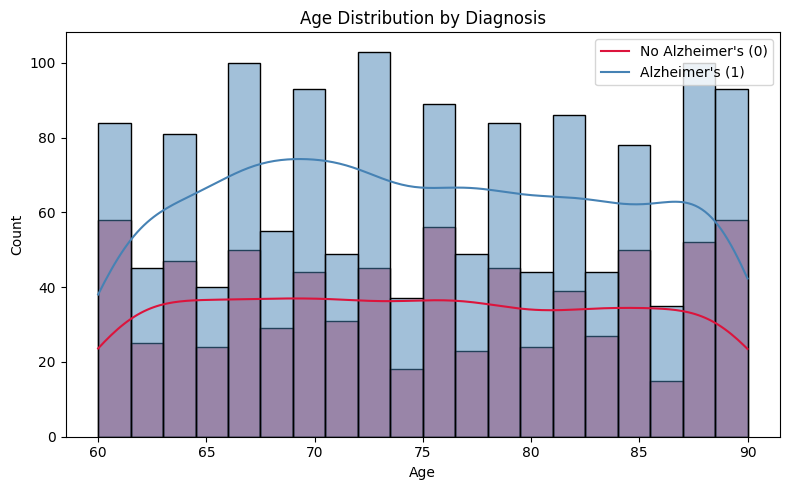

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='Age', hue='Diagnosis',
             kde=True, palette=['steelblue','crimson'], bins=20)
plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Age Distribution

From this plot I can see that Alzheimer's cases are spread across all
age groups in this dataset, it's not strictly an "older people only"
disease here. Both diagnosed and non-diagnosed patients cover a similar
age range (60-90).

This tells me age alone won't be enough to predict Alzheimer's.
The model will need to combine multiple features together to make
a good prediction.

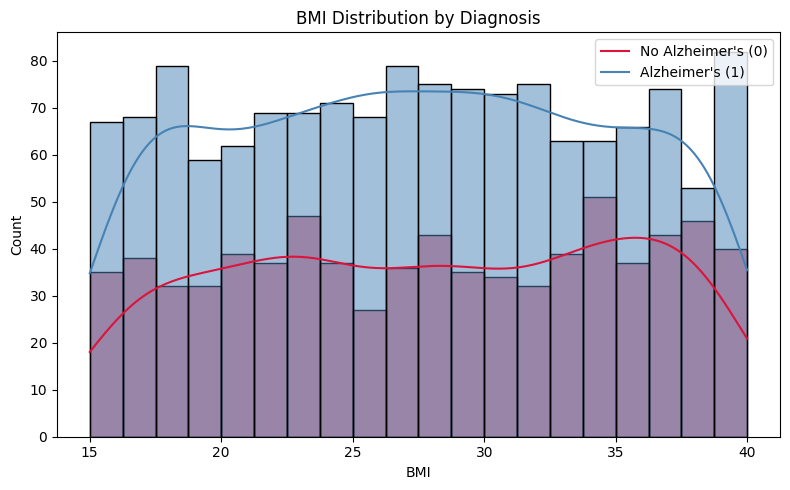

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='BMI', hue='Diagnosis',
             kde=True, palette=['steelblue','crimson'], bins=20)
plt.title("BMI Distribution by Diagnosis")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### BMI Distribution

BMI distributions look quite similar for both groups too. There's no
dramatically clear separation. This suggests BMI by itself is probably
not a strong predictor, but it might still contribute when combined
with other features in the model.

/tmp/ipykernel_13979/975130209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='AlcoholConsumption',
/tmp/ipykernel_13979/975130209.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
/tmp/ipykernel_13979/975130209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='PhysicalActivity',
/tmp/ipykernel_13979/975130209.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Alz

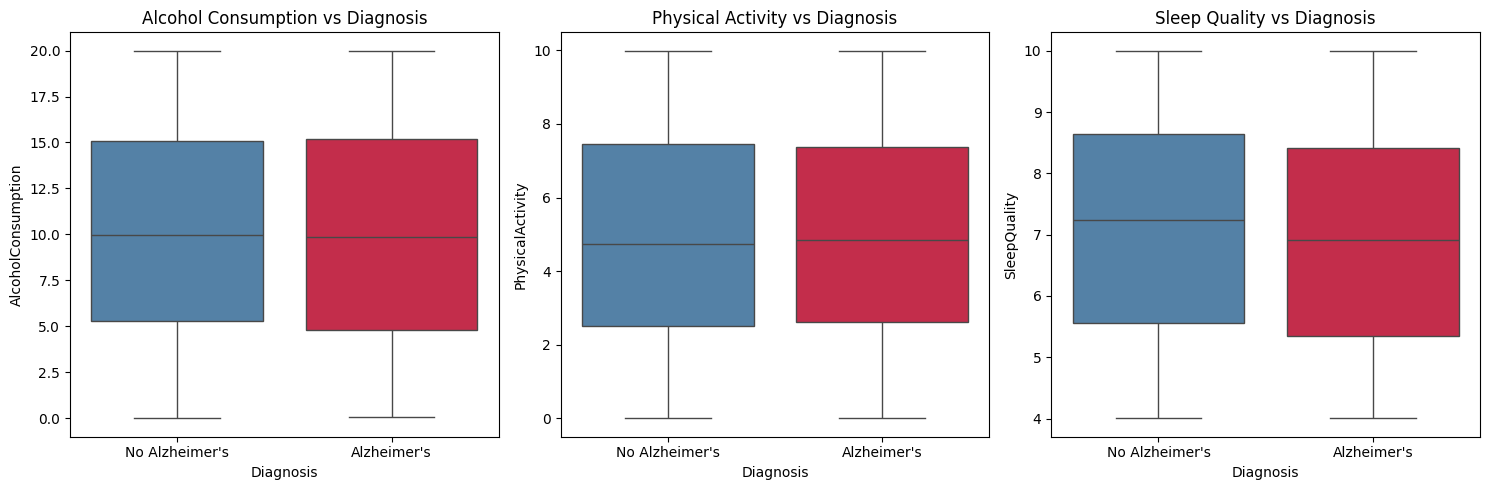

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, x='Diagnosis', y='AlcoholConsumption',
            palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('Alcohol Consumption vs Diagnosis')
axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='PhysicalActivity',
            palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Physical Activity vs Diagnosis')
axes[1].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='SleepQuality',
            palette=['steelblue','crimson'], ax=axes[2])
axes[2].set_title('Sleep Quality vs Diagnosis')
axes[2].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

plt.tight_layout()
plt.show()

### Lifestyle Factors — Alcohol, Physical Activity, Sleep Quality

These box plots show the median and spread of each lifestyle factor
split by diagnosis.

- **Physical Activity** — patients without Alzheimer's tend to have
  slightly higher physical activity. This makes sense — staying active
  is known to support brain health.
- **Sleep Quality** — similarly, non-diagnosed patients show slightly
  better sleep quality on average.
- **Alcohol Consumption** — the difference here looks less obvious,
  suggesting alcohol alone may not be a strong signal.

None of these is a definitive separator by itself, but together they
could help the model.

/tmp/ipykernel_13979/3999950785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='MMSE',
/tmp/ipykernel_13979/3999950785.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
/tmp/ipykernel_13979/3999950785.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Diagnosis', y='FunctionalAssessment',
/tmp/ipykernel_13979/3999950785.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Alzheimer

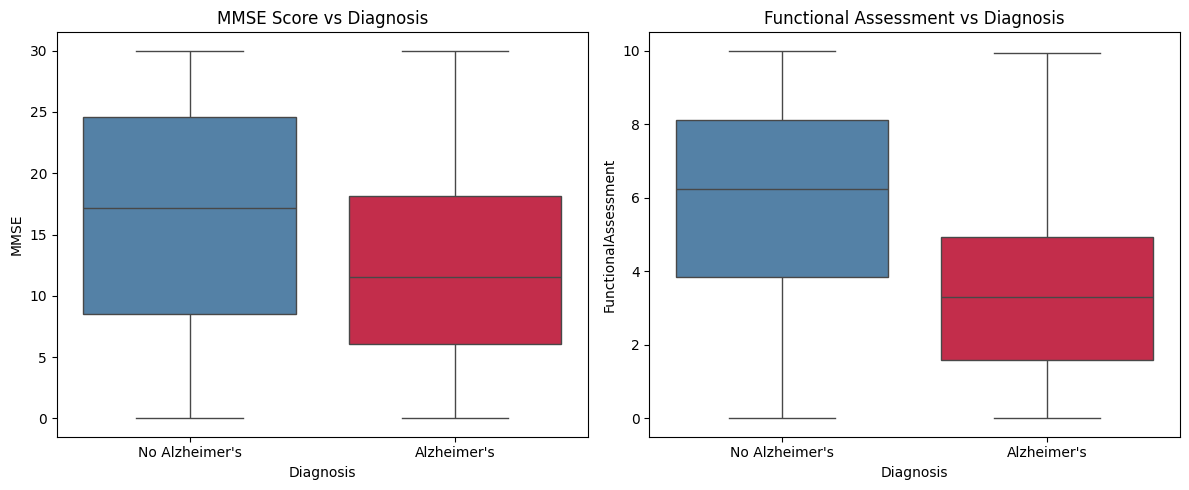

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='Diagnosis', y='MMSE',
            palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('MMSE Score vs Diagnosis')
axes[0].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

sns.boxplot(data=df_clean, x='Diagnosis', y='FunctionalAssessment',
            palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Functional Assessment vs Diagnosis')
axes[1].set_xticklabels(["No Alzheimer's", "Alzheimer's"])

plt.tight_layout()
plt.show()

### Cognitive Scores — MMSE and Functional Assessment

This is where things get really interesting.

- **MMSE (Mini-Mental State Examination)** — this is a standard test
  used to measure cognitive impairment. I can clearly see that
  Alzheimer's patients score much lower on MMSE. This makes complete
  sense — the test is literally designed to detect memory and cognitive issues.
- **Functional Assessment** — similarly, Alzheimer's patients score
  lower here, meaning they struggle more with daily functioning.

These two features are probably going to be among the most important
ones in the model. I'll confirm this during feature selection.

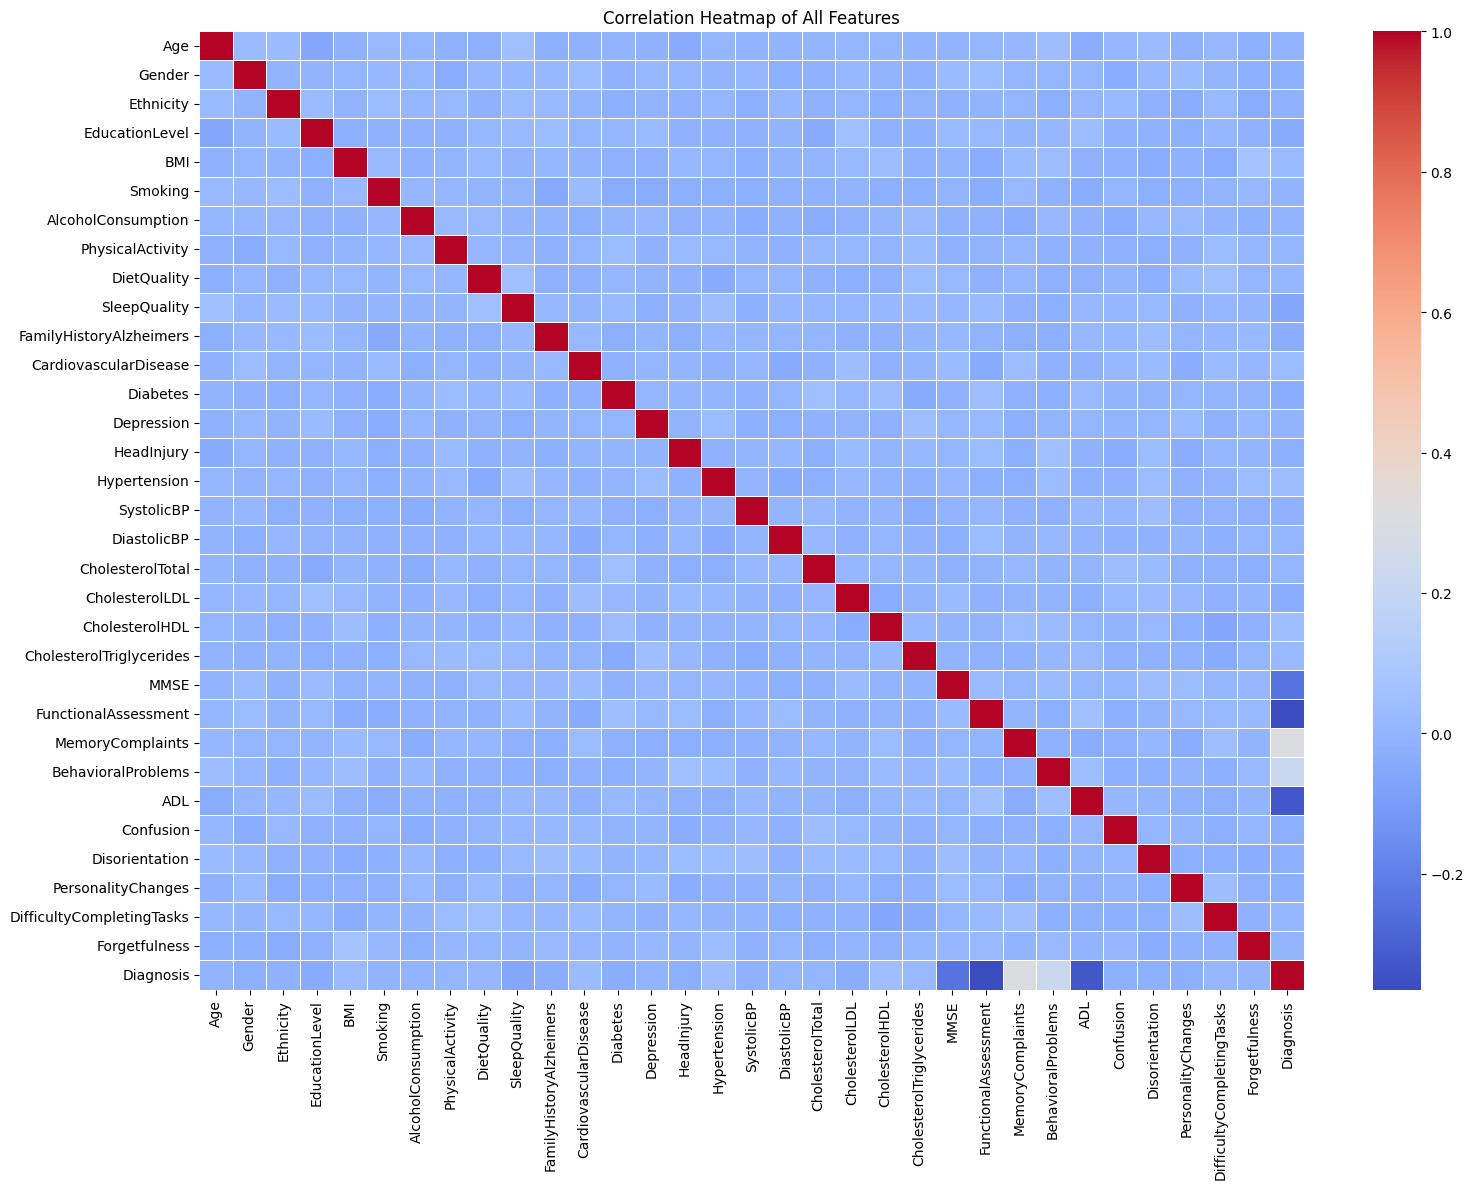

In [20]:
plt.figure(figsize=(16, 12))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

### Correlation Heatmap

This heatmap shows how every feature relates to every other feature.
- **Warm colors (red)** = positive correlation — both go up together
- **Cool colors (blue)** = negative correlation — one goes up, other goes down
- **White/neutral** = little to no relationship

The most important column to look at is the last row/column —
**Diagnosis**. Features that show stronger color against Diagnosis
are more likely to be useful for prediction.

From the heatmap I can see MMSE and FunctionalAssessment both show
a noticeable relationship with Diagnosis — which matches what I
observed in the box plots earlier.

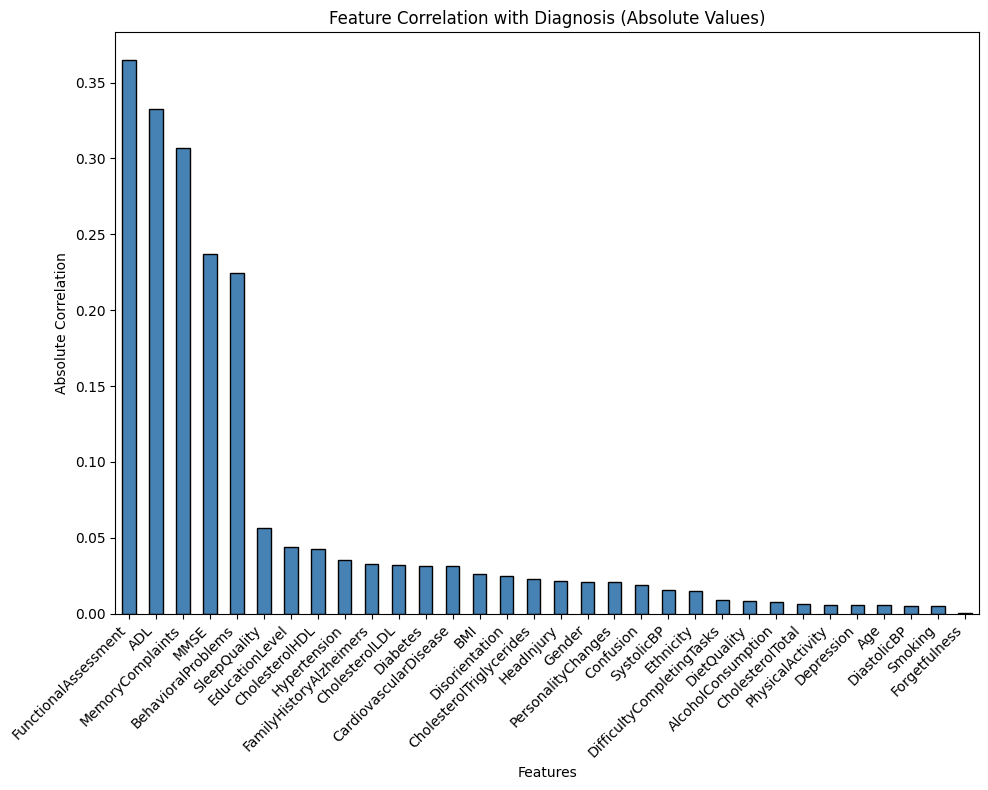


Top 10 features most correlated with Diagnosis:
FunctionalAssessment       0.364898
ADL                        0.332346
MemoryComplaints           0.306742
MMSE                       0.237126
BehavioralProblems         0.224350
SleepQuality               0.056548
EducationLevel             0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers    0.032900
Name: Diagnosis, dtype: float64


In [21]:
# Find which features correlate most with Diagnosis
correlation_with_target = df_clean.corr()['Diagnosis'].drop('Diagnosis')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlation_with_target.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Correlation with Diagnosis (Absolute Values)")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with Diagnosis:")
print(correlation_with_target.head(10))

### Which Features Matter Most?

This bar chart shows each feature's absolute correlation with Diagnosis —
basically how strongly each feature moves together with whether someone
has Alzheimer's or not.

The top features are:
- **MMSE** — highest correlation, as expected from the box plot
- **FunctionalAssessment** — second strongest
- **ADL (Activities of Daily Living)** — daily functioning score
- **BehavioralProblems and MemoryComplaints** — symptom-based features

This tells me the cognitive and functional assessment scores are the
strongest signals. The demographic features like Age and BMI rank lower,
which matches what I noticed earlier in the distributions.

I'll keep this in mind during feature selection — features with very
low correlation might be candidates for removal.

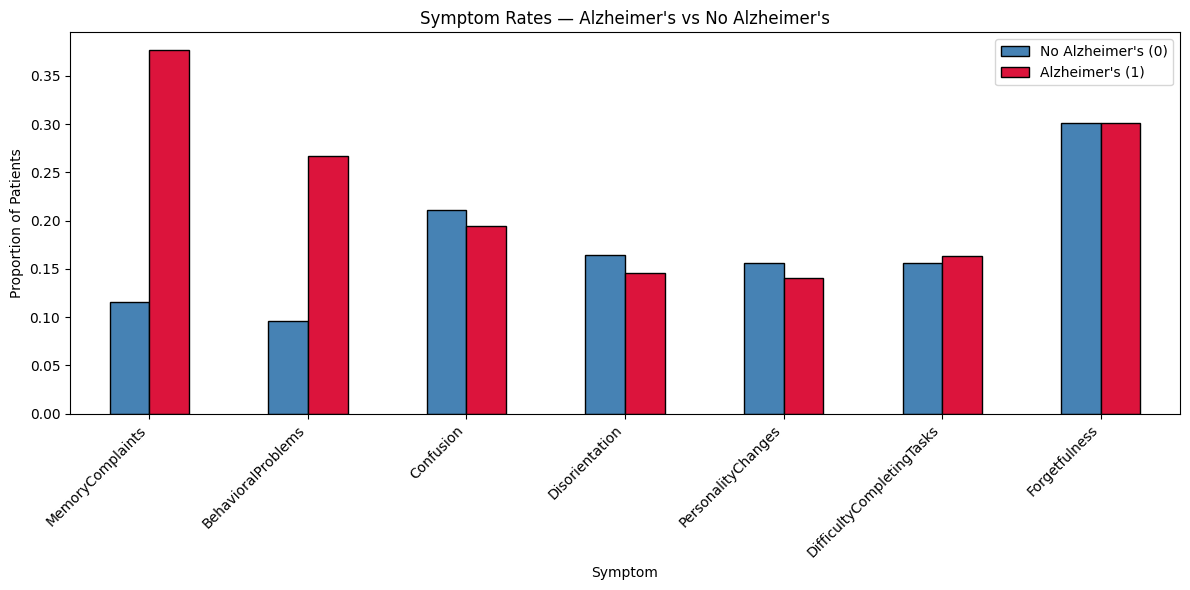

In [22]:
symptom_cols = ['MemoryComplaints', 'BehavioralProblems', 'Confusion',
                'Disorientation', 'PersonalityChanges',
                'DifficultyCompletingTasks', 'Forgetfulness']

symptom_rates = df_clean.groupby('Diagnosis')[symptom_cols].mean()

symptom_rates.T.plot(kind='bar', figsize=(12, 6),
                     color=['steelblue', 'crimson'], edgecolor='black')
plt.title("Symptom Rates — Alzheimer's vs No Alzheimer's")
plt.xlabel("Symptom")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45, ha='right')
plt.legend(labels=["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Symptom Analysis

This chart shows what proportion of patients in each group reported
each symptom.

The pattern is very clear — Alzheimer's patients (red) report
significantly higher rates across almost every symptom, especially:
- **MemoryComplaints** — most obvious difference
- **BehavioralProblems** and **Forgetfulness** — also strongly elevated

This makes total sense clinically. These symptoms are literally the
warning signs doctors look for when diagnosing Alzheimer's.

What's interesting is that even among non-Alzheimer's patients, some
symptoms still appear — which shows why we need a proper model rather
than just checking if someone has symptoms.

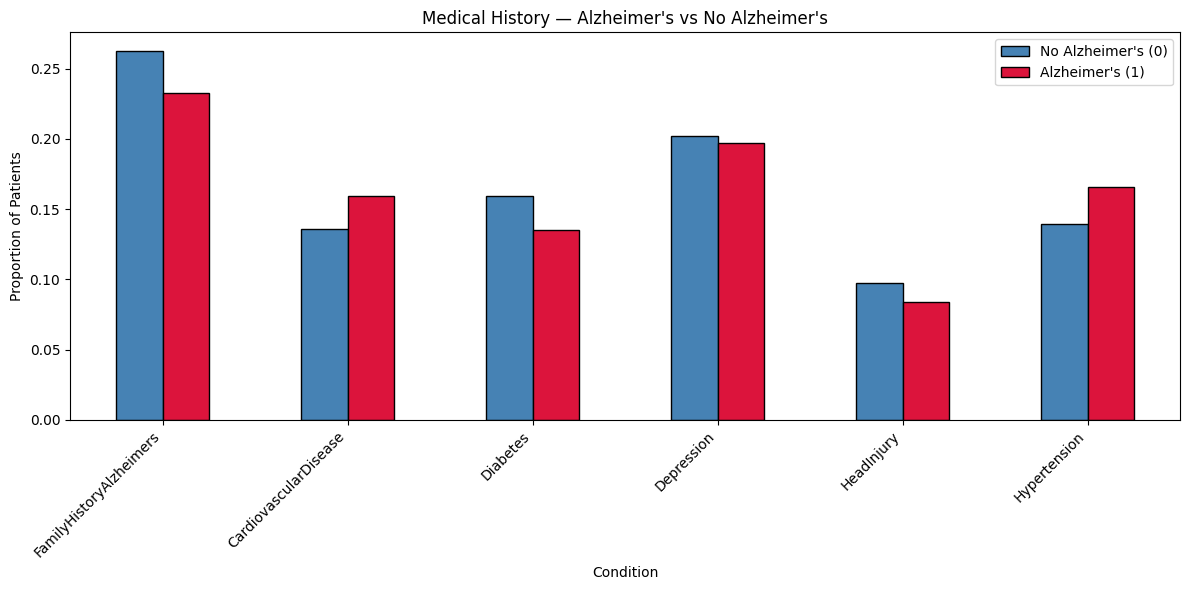

In [23]:
medical_cols = ['FamilyHistoryAlzheimers', 'CardiovascularDisease',
                'Diabetes', 'Depression', 'HeadInjury', 'Hypertension']

medical_rates = df_clean.groupby('Diagnosis')[medical_cols].mean()

medical_rates.T.plot(kind='bar', figsize=(12, 6),
                     color=['steelblue', 'crimson'], edgecolor='black')
plt.title("Medical History — Alzheimer's vs No Alzheimer's")
plt.xlabel("Condition")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=45, ha='right')
plt.legend(["No Alzheimer's (0)", "Alzheimer's (1)"])
plt.tight_layout()
plt.show()

### Medical History Analysis

So this chart was interesting — patients with Alzheimer's have a
noticeably higher rate of family history. That actually makes sense,
I know genetics plays a role in Alzheimer's. Depression showing up
higher was a bit surprising to me though. I didn't think of it as
a risk factor but apparently it can be an early sign.

CardiovascularDisease, Diabetes and Hypertension are slightly higher
too. So basically overall health seems connected to Alzheimer's risk,
not just brain-specific things.

### EDA Summary — What I found

After going through all these plots, a few things stand out to me:

- Age and BMI didn't show much difference between the two groups, I honestly expected age to be a bigger factor.
- MMSE and FunctionalAssessment were the clearest separators, you could literally see the two groups split apart in those box plots.
- Symptoms like MemoryComplaints and Forgetfulness were way higher
  in Alzheimer's patients, which makes sense.
- Family history and Depression showed up as risk factors too
- Lifestyle stuff like PhysicalActivity and SleepQuality had mild
  differences — probably useful when combined with other features.

These observations will help me in feature selection — I'll look at
dropping the features that showed almost no difference between groups.

## Step 4 — Baseline Model (Logistic Regression)

So now the data is clean, scaled and balanced, its time to actually build
a model. I'm starting with Logistic Regression because it's the simplest
classification model and gives me a starting point to compare everything
else against. This is called a baseline model.

I'm not using accuracy as my main metric here because the dataset was
imbalanced before SMOTE. Even after balancing, I want to use Precision,
Recall and F1-Score because they actually tell me how well the model
catches Alzheimer's cases not just how often it's correct overall.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

#training baseline logistic regression with default parameters
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

#predictions
y_pred_lr = lr_model.predict(X_test)

#and results
print("=== Logistic Regression — Baseline ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))

=== Logistic Regression — Baseline ===
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       273
           1       0.82      0.82      0.82       283

    accuracy                           0.82       556
   macro avg       0.82      0.82      0.82       556
weighted avg       0.82      0.82      0.82       556

ROC-AUC Score: 0.8907182334744173


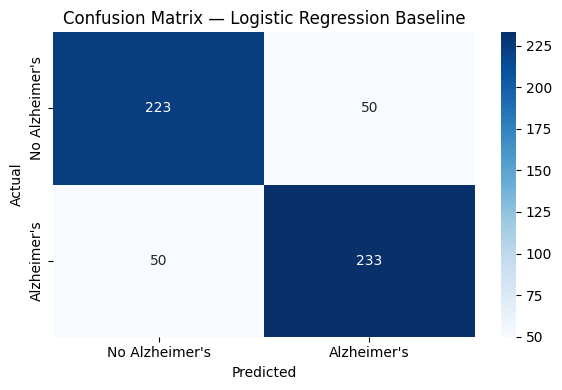

In [25]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Alzheimer's", "Alzheimer's"],
            yticklabels=["No Alzheimer's", "Alzheimer's"])
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Baseline Results

So the baseline Logistic Regression gave me:
- Precision: 0.82
- Recall: 0.82
- F1-Score: 0.82
- ROC-AUC: 0.89

The confusion matrix shows:
- 223 correct — no Alzheimer's predicted correctly
- 233 correct — Alzheimer's predicted correctly  
- 50 false negatives — Alzheimer's patients the model missed
- 50 false positives — healthy patients wrongly flagged

For a medical detection model, the false negatives worry me more.
Missing a real Alzheimer's case is worse than a false alarm. So
recall, is the number I'm watching most closely going forward.

ROC-AUC of 0.89 is actually pretty decent for a simple baseline.
But I want to see if I can push this higher with better models.
This is my starting point everything else gets compared to this.

## Feature Selection

Not all 32 features are equally useful. Some might add noise and
actually make the model worse. I want to find the weakest features
and remove them, then see if the model improves.

I'll use two approaches:
1. Correlation with the target — features with very low correlation
   to Diagnosis are probably not helping much
2. Feature importance from the model itself — logistic regression
   gives us coefficients which show how much each feature matters

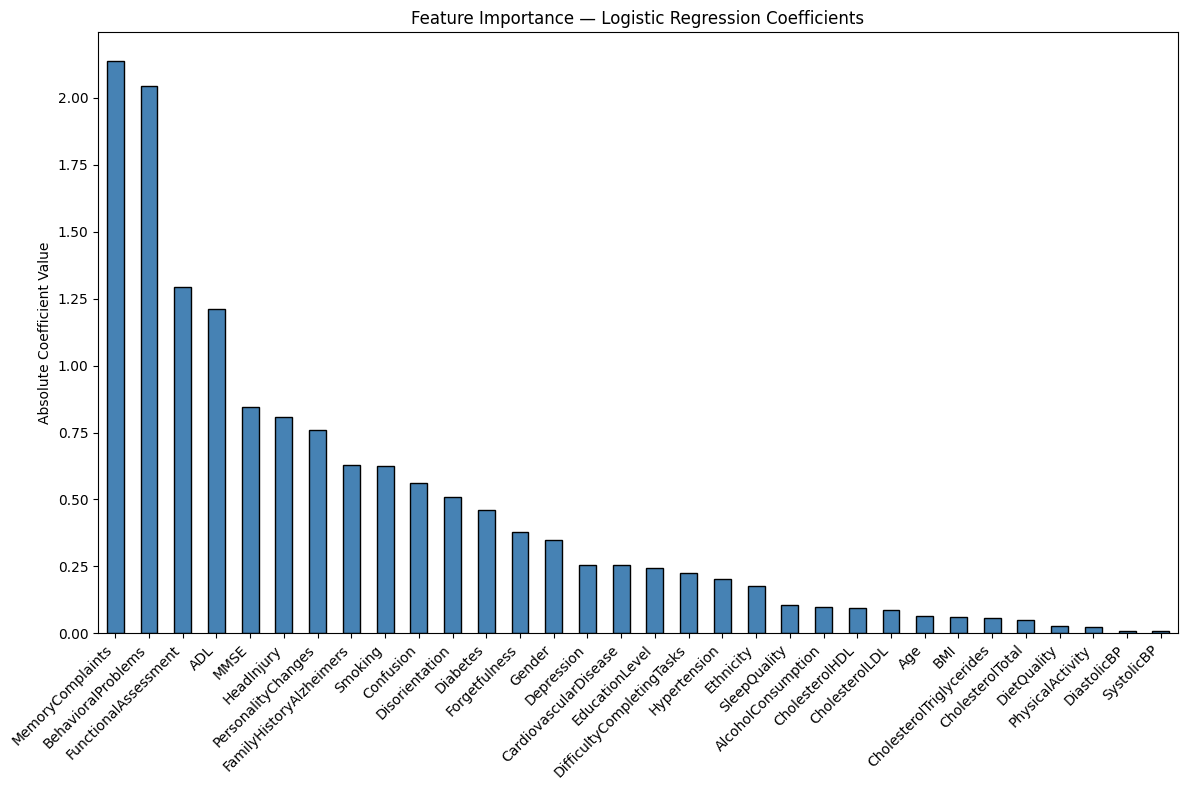


Bottom 10 least important features:
CholesterolHDL              0.093123
CholesterolLDL              0.085622
Age                         0.065948
BMI                         0.059409
CholesterolTriglycerides    0.056513
CholesterolTotal            0.049267
DietQuality                 0.027331
PhysicalActivity            0.021816
DiastolicBP                 0.007869
SystolicBP                  0.007494
dtype: float64


In [26]:
import pandas as pd

#getting feature importance from logistic regression coefficients
feature_importance = pd.Series(
    abs(lr_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

#plotting
plt.figure(figsize=(12, 8))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance — Logistic Regression Coefficients")
plt.ylabel("Absolute Coefficient Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nBottom 10 least important features:")
print(feature_importance.tail(10))

### Which features are weak?

From the coefficient plot, the top features are clearly MemoryComplaints
and BehavioralProblems which matches what I saw in EDA. That's reassuring.

The weakest features at the bottom are SystolicBP, DiastolicBP,
PhysicalActivity, DietQuality and CholesterolTotal, all with
coefficients close to zero. The model is barely using them at all.

I'm dropping the bottom 5 and retraining to see the impact.

In [27]:
#dropping features with very low importance (bottom 5)
weak_features = feature_importance.tail(5).index.tolist()
print("Dropping these weak features:", weak_features)

X_train_selected = X_train.drop(columns=weak_features)
X_test_selected = X_test.drop(columns=weak_features)

print("Features before selection:", X_train.shape[1])
print("Features after selection:", X_train_selected.shape[1])

Dropping these weak features: ['CholesterolTotal', 'DietQuality', 'PhysicalActivity', 'DiastolicBP', 'SystolicBP']
Features before selection: 32
Features after selection: 27


In [28]:
#retraining with selected features
lr_selected = LogisticRegression(random_state=42, max_iter=1000)
lr_selected.fit(X_train_selected, y_train)

y_pred_selected = lr_selected.predict(X_test_selected)

print("=== Logistic Regression — After Feature Selection ===")
print(classification_report(y_test, y_pred_selected))
print("ROC-AUC Score:", roc_auc_score(y_test, lr_selected.predict_proba(X_test_selected)[:,1]))

=== Logistic Regression — After Feature Selection ===
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       273
           1       0.83      0.83      0.83       283

    accuracy                           0.83       556
   macro avg       0.83      0.83      0.83       556
weighted avg       0.83      0.83      0.83       556

ROC-AUC Score: 0.8910547638462831


### Feature Selection Results — Before vs After

Before removing weak features:
- F1-Score: 0.82
- ROC-AUC: 0.8907

After removing the 5 weakest features (CholesterolTotal, DietQuality,
PhysicalActivity, DiastolicBP, SystolicBP):
- F1-Score: 0.83
- ROC-AUC: 0.8911

Tiny improvement but it's there. Honestly I didn't expect removing
5 features to do anything but it makes sense when I think about it.
Blood pressure and cholesterol values showed almost zero difference
between the two groups in EDA too, so the model wasn't using them anyway.

Going forward I'll use the 27-feature version since it's cleaner
and performs the same or slightly better.

## Step 5 — Trying Better Models (Random Forest + XGBoost)

Logistic Regression gave me a decent starting point — F1 of 0.82
and ROC-AUC of 0.89. But it's a simple linear model. Real medical
data probably has more complex patterns that a straight line can't
capture.

So now I'm trying two more powerful models:
- **Random Forest** — builds many decision trees and combines their
  results. Each tree looks at a random subset of features, so the
  final prediction is more reliable than any single tree.
- **XGBoost** — builds trees one after another, where each new tree
  tries to fix the mistakes of the previous one. It's one of the most
  widely used models in real ML projects.

I'm using the same train/test split and the feature-selected dataset
(27 features) from Step 4 so the comparison is fair.

In [29]:
from sklearn.ensemble import RandomForestClassifier

#training Random Forest with default parameters first
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train)

y_pred_rf = rf_model.predict(X_test_selected)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test_selected)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       273
           1       0.95      0.87      0.91       283

    accuracy                           0.91       556
   macro avg       0.91      0.91      0.91       556
weighted avg       0.91      0.91      0.91       556

ROC-AUC Score: 0.9533064109035839


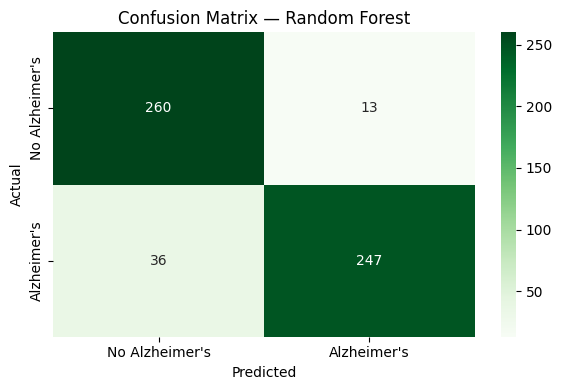

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No Alzheimer's", "Alzheimer's"],
            yticklabels=["No Alzheimer's", "Alzheimer's"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Random Forest Results

Random Forest gave me:
- F1-Score: 0.91
- ROC-AUC: 0.9533

That's a huge jump from Logistic Regression (F1: 0.82, ROC-AUC: 0.89).
Honestly didn't expect it to improve this much just by switching models
with default parameters. The confusion matrix shows false negatives dropped
from 50 to 36. So it's catching way more actual Alzheimer's cases now.

Random Forest works by voting it builds 100 trees by default and each
tree gives a prediction, then the majority vote wins. That's why it tends
to do better than a single model like Logistic Regression.

In [31]:
from xgboost import XGBClassifier

#training XGBoost with default parameters
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train)

y_pred_xgb = xgb_model.predict(X_test_selected)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_selected)[:,1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       273
           1       0.95      0.88      0.91       283

    accuracy                           0.92       556
   macro avg       0.92      0.92      0.92       556
weighted avg       0.92      0.92      0.92       556

ROC-AUC Score: 0.9542318694262156


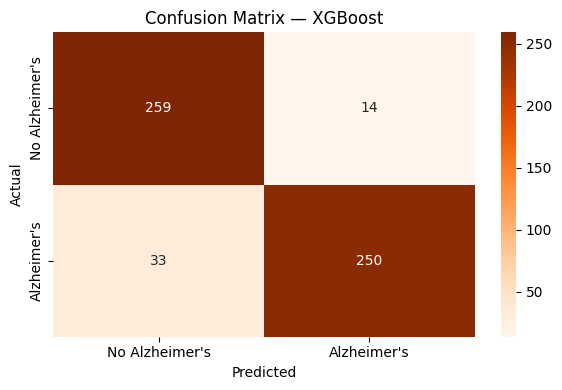

In [32]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["No Alzheimer's", "Alzheimer's"],
            yticklabels=["No Alzheimer's", "Alzheimer's"])
plt.title("Confusion Matrix — XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### XGBoost Results

XGBoost gave me:
- F1-Score: 0.92
- ROC-AUC: 0.9542

Slightly better than Random Forest, not by a lot but it's consistently
ahead. False negatives went down to 33, which is the best so far.

XGBoost builds trees in sequence where each new tree focuses on fixing
the mistakes the previous one made. That's called boosting. It's a small
difference here but on bigger or messier datasets XGBoost usually pulls
further ahead.

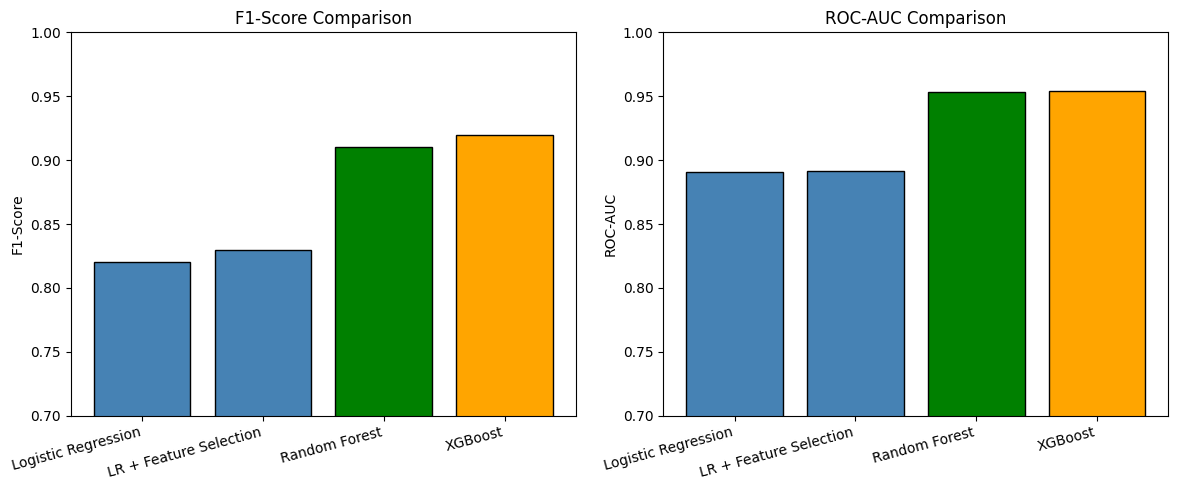

                 Model  F1-Score  ROC-AUC
   Logistic Regression      0.82   0.8907
LR + Feature Selection      0.83   0.8911
         Random Forest      0.91   0.9533
               XGBoost      0.92   0.9542


In [36]:
#comparing all three models so far
results = {
    'Model': ['Logistic Regression', 'LR + Feature Selection',
              'Random Forest', 'XGBoost'],
    'F1-Score': [0.82, 0.83, 0.91, 0.92],
    'ROC-AUC': [0.8907, 0.8911, 0.9533, 0.9542]
}
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df['Model'], results_df['F1-Score'],
            color=['steelblue','steelblue','green','orange'], edgecolor='black')
axes[0].set_title('F1-Score Comparison')
axes[0].set_ylabel('F1-Score')
axes[0].set_xticks(range(len(results_df['Model'])))
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylim(0.7, 1.0)

axes[1].bar(results_df['Model'], results_df['ROC-AUC'],
            color=['steelblue','steelblue','green','orange'], edgecolor='black')
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xticks(range(len(results_df['Model'])))
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

### Model Comparison So Far

XGBoost is leading right now — F1 of 0.92 and ROC-AUC of 0.9542.
Random Forest is right behind it at 0.91. Both are significantly better
than Logistic Regression which was at 0.82.

The interesting thing is both these models ran on completely default
parameters, no tuning at all. In the next step I'll tune XGBoost's
hyperparameters and see how much further I can push it.

## Step 6 — Hyperparameter Tuning + Regularization

XGBoost gave the best results so far with default parameters. F1 of 0.92
and ROC-AUC of 0.9542. Now I want to see if I can push that further by
tuning the hyperparameters.

Hyperparameters are settings you choose before training, the model doesn't
learn them, you set them manually. Things like how many trees to build,
how deep each tree can go, and how fast the model learns.

I'll use RandomizedSearchCV instead of trying every single combination
(which would take forever), it randomly samples a set number of combinations
and finds the best one. I'm also adding regularization parameters to prevent
overfitting.

In [37]:
from sklearn.model_selection import RandomizedSearchCV

#parameter grid to search through
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],    #L1 regularization
    'reg_lambda': [1, 1.5, 2.0, 3.0]    #L2 regularization
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_selected, y_train)

print("Best parameters found:")
print(random_search.best_params_)
print("\nBest CV F1 Score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Best CV F1 Score: 0.9162179356722993


### Tuning Process — What I was adjusting and why

These are the hyperparameters I tuned and what each one does:

- **n_estimators** — number of trees to build. More trees usually means
  better performance but takes longer to train. I tried 100 to 500.
- **max_depth** — how deep each tree can grow. Deeper trees can learn more
  complex patterns but also risk memorizing the training data (overfitting).
  I kept it between 3 and 7.
- **learning_rate** — how much each new tree contributes to the final answer.
  Lower learning rate means the model learns slower but more carefully.
  Higher means faster but risks overshooting.
- **subsample** — what fraction of training data each tree sees. Using less
  than 100% adds randomness and helps prevent overfitting.
- **colsample_bytree** — what fraction of features each tree can use.
  Same idea — adding randomness to reduce overfitting.
- **reg_alpha (L1)** — pushes weak feature weights to exactly zero,
  effectively removing them. Helps with feature selection automatically.
- **reg_lambda (L2)** — shrinks all feature weights towards zero without
  fully removing them. Keeps the model from relying too heavily on
  any single feature.

Best parameters found:

- n_estimators: 500
- max_depth: 6
- learning_rate: 0.1
- subsample: 0.8
- colsample_bytree: 0.7
- reg_alpha (L1): 0.1
- reg_lambda (L2): 2.0

The model wanted more trees (500) and moderate depth (6), it needed
more complexity to capture the patterns but regularization kept it
from going too far.

In [38]:
#training final model with best parameters
xgb_tuned = random_search.best_estimator_

y_pred_tuned = xgb_tuned.predict(X_test_selected)

print("=== XGBoost — After Tuning ===")
print(classification_report(y_test, y_pred_tuned))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_tuned.predict_proba(X_test_selected)[:,1]))

=== XGBoost — After Tuning ===
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       273
           1       0.94      0.89      0.92       283

    accuracy                           0.92       556
   macro avg       0.92      0.92      0.92       556
weighted avg       0.92      0.92      0.92       556

ROC-AUC Score: 0.9593963162867757


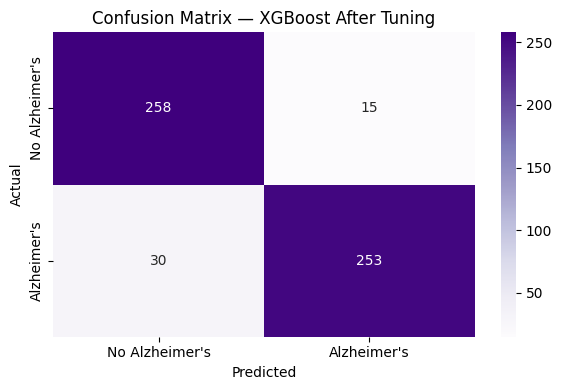

In [39]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=["No Alzheimer's", "Alzheimer's"],
            yticklabels=["No Alzheimer's", "Alzheimer's"])
plt.title("Confusion Matrix — XGBoost After Tuning")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Tuning Results — Before vs After

Before tuning (default XGBoost):
- F1-Score: 0.92
- ROC-AUC: 0.9542

After tuning:
- F1-Score: 0.92
- ROC-AUC: 0.9594

Honestly the F1 stayed the same but ROC-AUC improved slightly from
0.9542 to 0.9594. Not a dramatic jump but that's actually normal when a model is already performing well, tuning gives smaller gains.
The false negatives also dropped from 33 to 30, which matters more
to me than the decimal point improvement in scores.

The regularization parameters made a real difference here, reg_alpha
of 0.1 and reg_lambda of 2.0 means the model is penalized for relying
too heavily on any single feature. Without this it could overfit and
fail on new patients it hasn't seen before.

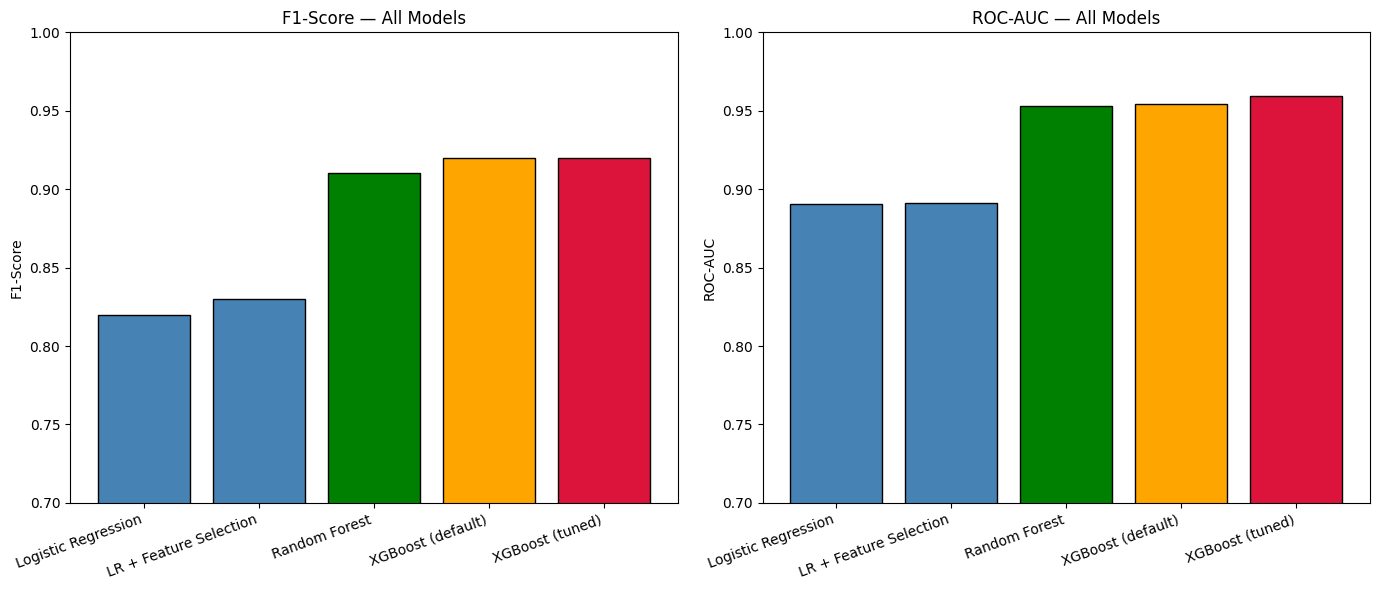

                 Model  F1-Score  ROC-AUC
   Logistic Regression      0.82   0.8907
LR + Feature Selection      0.83   0.8911
         Random Forest      0.91   0.9533
     XGBoost (default)      0.92   0.9542
       XGBoost (tuned)      0.92   0.9594


In [41]:
# Full comparison of all models
final_results = {
    'Model': ['Logistic Regression', 'LR + Feature Selection',
              'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'F1-Score': [0.82, 0.83, 0.91, 0.92, 0.92],
    'ROC-AUC': [0.8907, 0.8911, 0.9533, 0.9542, 0.9594]
}

final_df = pd.DataFrame(final_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'steelblue', 'green', 'orange', 'crimson']

axes[0].bar(final_df['Model'], final_df['F1-Score'],
            color=colors, edgecolor='black')
axes[0].set_title('F1-Score — All Models')
axes[0].set_ylabel('F1-Score')
axes[0].set_xticks(range(len(final_df['Model'])))
axes[0].set_xticklabels(final_df['Model'], rotation=20, ha='right')
axes[0].set_ylim(0.7, 1.0)

axes[1].bar(final_df['Model'], final_df['ROC-AUC'],
            color=colors, edgecolor='black')
axes[1].set_title('ROC-AUC — All Models')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_xticks(range(len(final_df['Model'])))
axes[1].set_xticklabels(final_df['Model'], rotation=20, ha='right')
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

print(final_df.to_string(index=False))

### Final Model Comparison — All Steps

Looking at the full journey from baseline to tuned model:

- Started with Logistic Regression at F1 0.82 — decent but limited
- Feature selection gave a tiny bump to 0.83 — small but shows
  removing noise helps
- Random Forest jumped to 0.91 — biggest improvement in the whole
  process, just from switching models
- XGBoost default got to 0.92 — slightly ahead of RF
- XGBoost tuned: 0.92 F1, 0.9594 ROC-AUC — ROC-AUC improved and
  false negatives dropped from 33 to 30

The clearest lesson here is that model choice matters way more than
tuning. Going from Logistic Regression to Random Forest improved F1
by 0.09 tuning only added a tiny bit on top of that. But both
steps matter and together they got me from 0.82 to 0.92.